# 1) Chargement des données

In [ ]:
# cell: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import joblib

RND = 42


In [ ]:

# activer l'API expérimentale si nécessaire
from sklearn.experimental import enable_iterative_imputer

In [ ]:
# import des imputeurs
from sklearn.impute import IterativeImputer, KNNImputer

In [ ]:
# autres imports utiles
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_orig = pd.read_csv('/content/billets.csv', sep=';')
df = df_orig.copy()   # df = working copy



In [ ]:
# 1. Descriptives
print(df.info())
print(df.describe())
print("NaN par colonne:\n", df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB
None
          diagonal  height_left  height_right   margin_low    margin_up  \
count  1500.000000  1500.000000   1500.000000  1463.000000  1500.000000   
mean    171.958440   104.029533    103.920307     4.485967     3.151473   
std       0.305195     0.299462      0.325627     0.663813     0.231813   
min     171.040000   103.140000    102.820000     2.980000     2.270000   
25%     171.750000   103.820000    103.710000     4.015000     2.990000   
50

<Axes: >

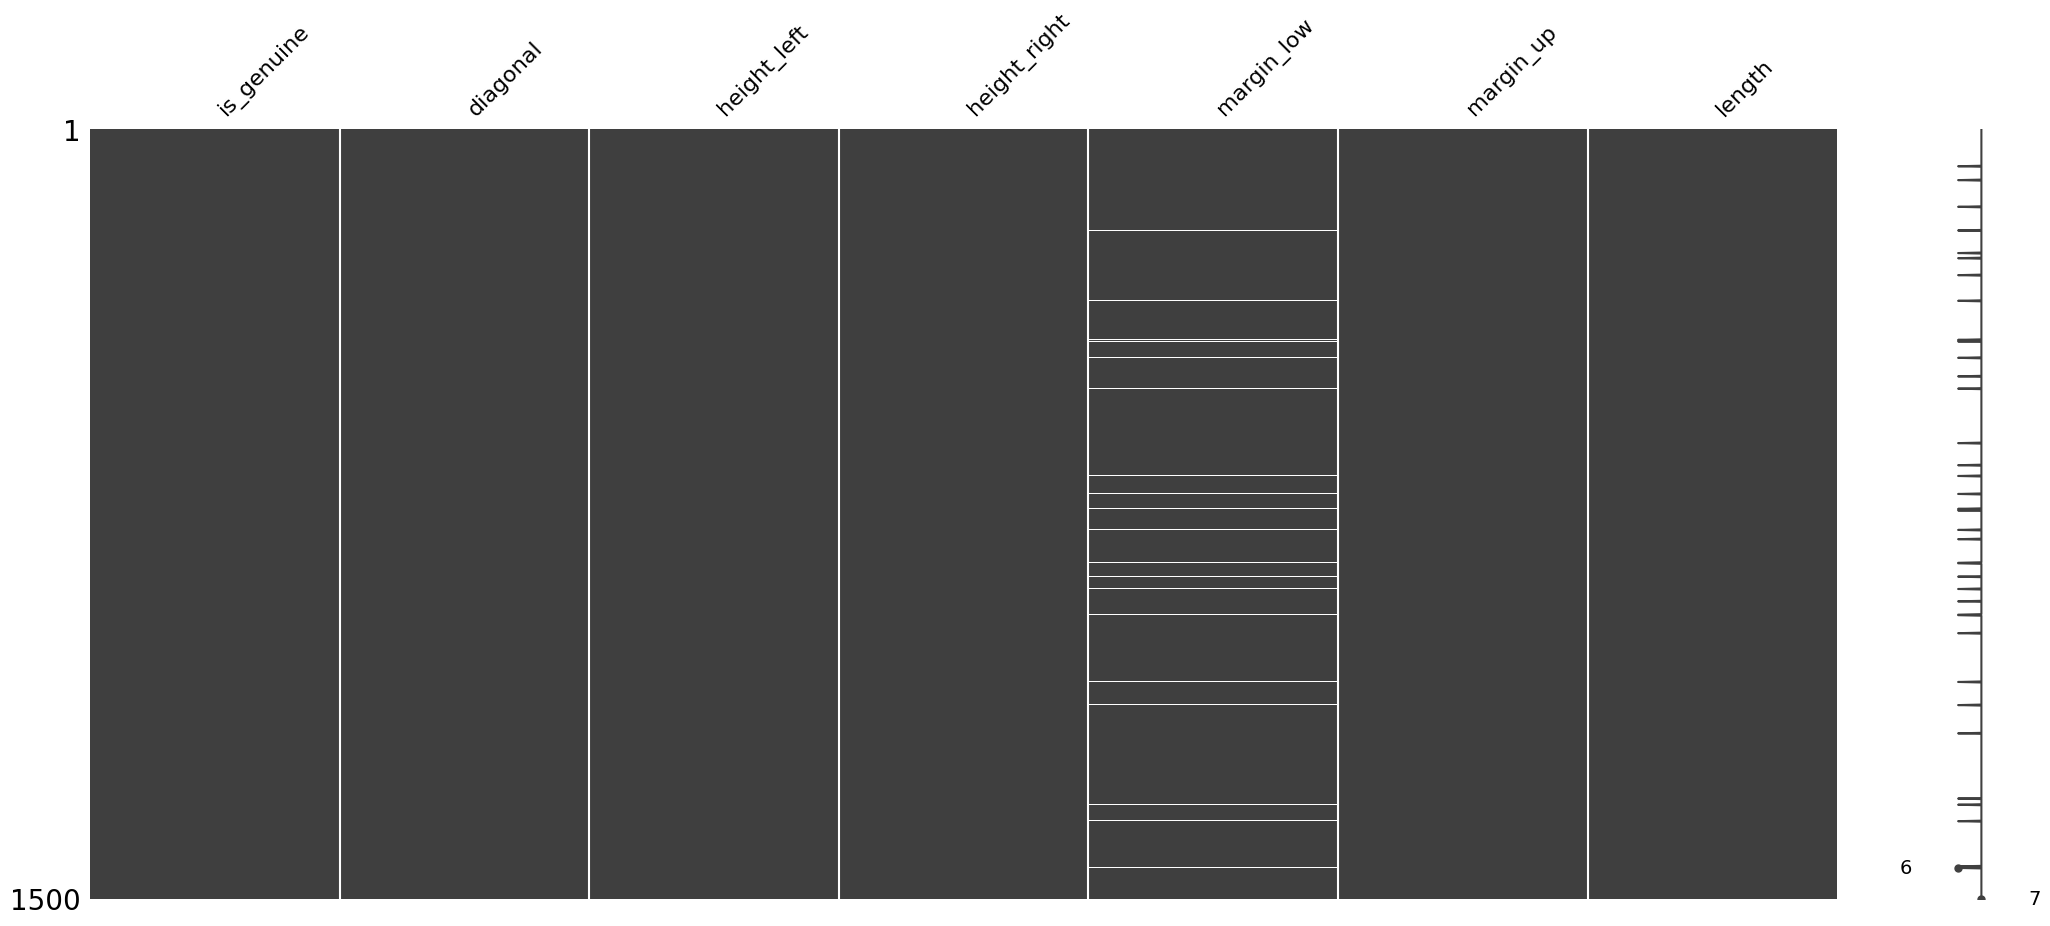

In [ ]:
msno.matrix(df)

In [ ]:
# Nombre de valeurs distinctes

distinct_count = df['is_genuine'].nunique
print(distinct_count)

<bound method IndexOpsMixin.nunique of 0        True
1        True
2        True
3        True
4        True
        ...  
1495    False
1496    False
1497    False
1498    False
1499    False
Name: is_genuine, Length: 1500, dtype: bool>


In [ ]:
counts = df['is_genuine'].value_counts()          # ignore NaN
counts_with_nan = df['is_genuine'].value_counts(dropna=False)  # inclut NaN
print(counts)

is_genuine
True     1000
False     500
Name: count, dtype: int64


In [ ]:
# 3. Corrélations
predictors = ['length','margin_up','height_left','height_right','diagonal']
X = df[predictors].dropna().copy()

# 1) diagnostics rapides
print("Variances:\n", X.var())
print("Nunique par colonne:\n", X.nunique())
print("Corr matrix:\n", X.corr().round(3))
print("Condition number:", np.linalg.cond((X - X.mean()).values))

# 2) VIF correct
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns)
print("VIF (statsmodels):\n", vif)

# 3) Vérification alternative via R2
for col in X.columns:
    y = X[col].values
    X_others = X.drop(columns=[col]).values
    lr = LinearRegression().fit(X_others, y)
    r2 = lr.score(X_others, y)
    print(f"{col} : R2 = {r2:.6f} -> VIF = {1/(1-r2):.6f}")


Variances:
 length          0.761657
margin_up       0.053737
height_left     0.089677
height_right    0.106033
diagonal        0.093144
dtype: float64
Nunique par colonne:
 length          336
margin_up       123
height_left     155
height_right    170
diagonal        159
dtype: int64
Corr matrix:
               length  margin_up  height_left  height_right  diagonal
length         1.000     -0.521       -0.321        -0.402     0.098
margin_up     -0.521      1.000        0.247         0.307    -0.056
height_left   -0.321      0.247        1.000         0.242     0.019
height_right  -0.402      0.307        0.242         1.000    -0.024
diagonal       0.098     -0.056        0.019        -0.024     1.000
Condition number: 4.6585053358668125
VIF (statsmodels):
 length           22676.458356
margin_up          260.785987
height_left     112879.408271
height_right    100054.247709
diagonal        169341.929149
dtype: float64
length : R2 = 0.364984 -> VIF = 1.574765
margin_up : R2 = 0.287

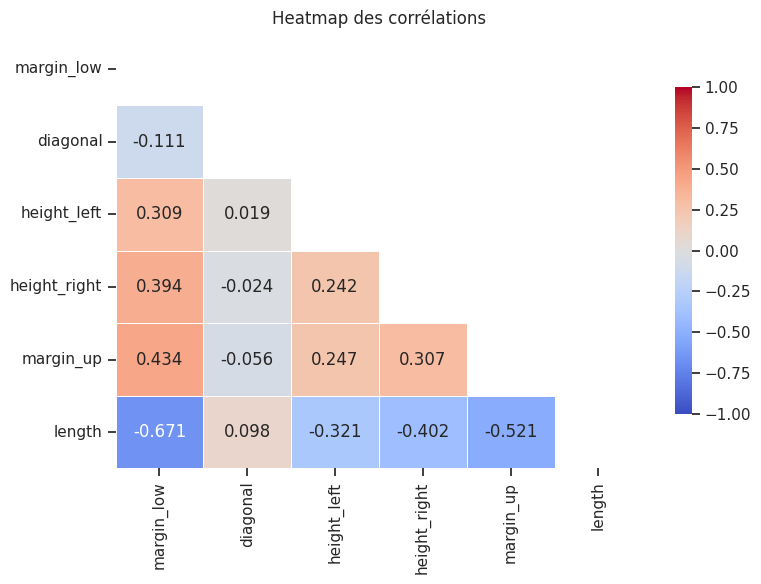

In [ ]:
# Visualiser heatmap des corrélations

cols = ['margin_low'] + predictors

# DataFrame pour la corrélation (pas de dropna nécessaire si pas de NaN)
df_corr = df[cols].copy()

# matrice de corrélation
corr = df_corr.corr()

# masque pour triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink":0.75})
plt.title("Heatmap des corrélations")
plt.tight_layout()
plt.show()


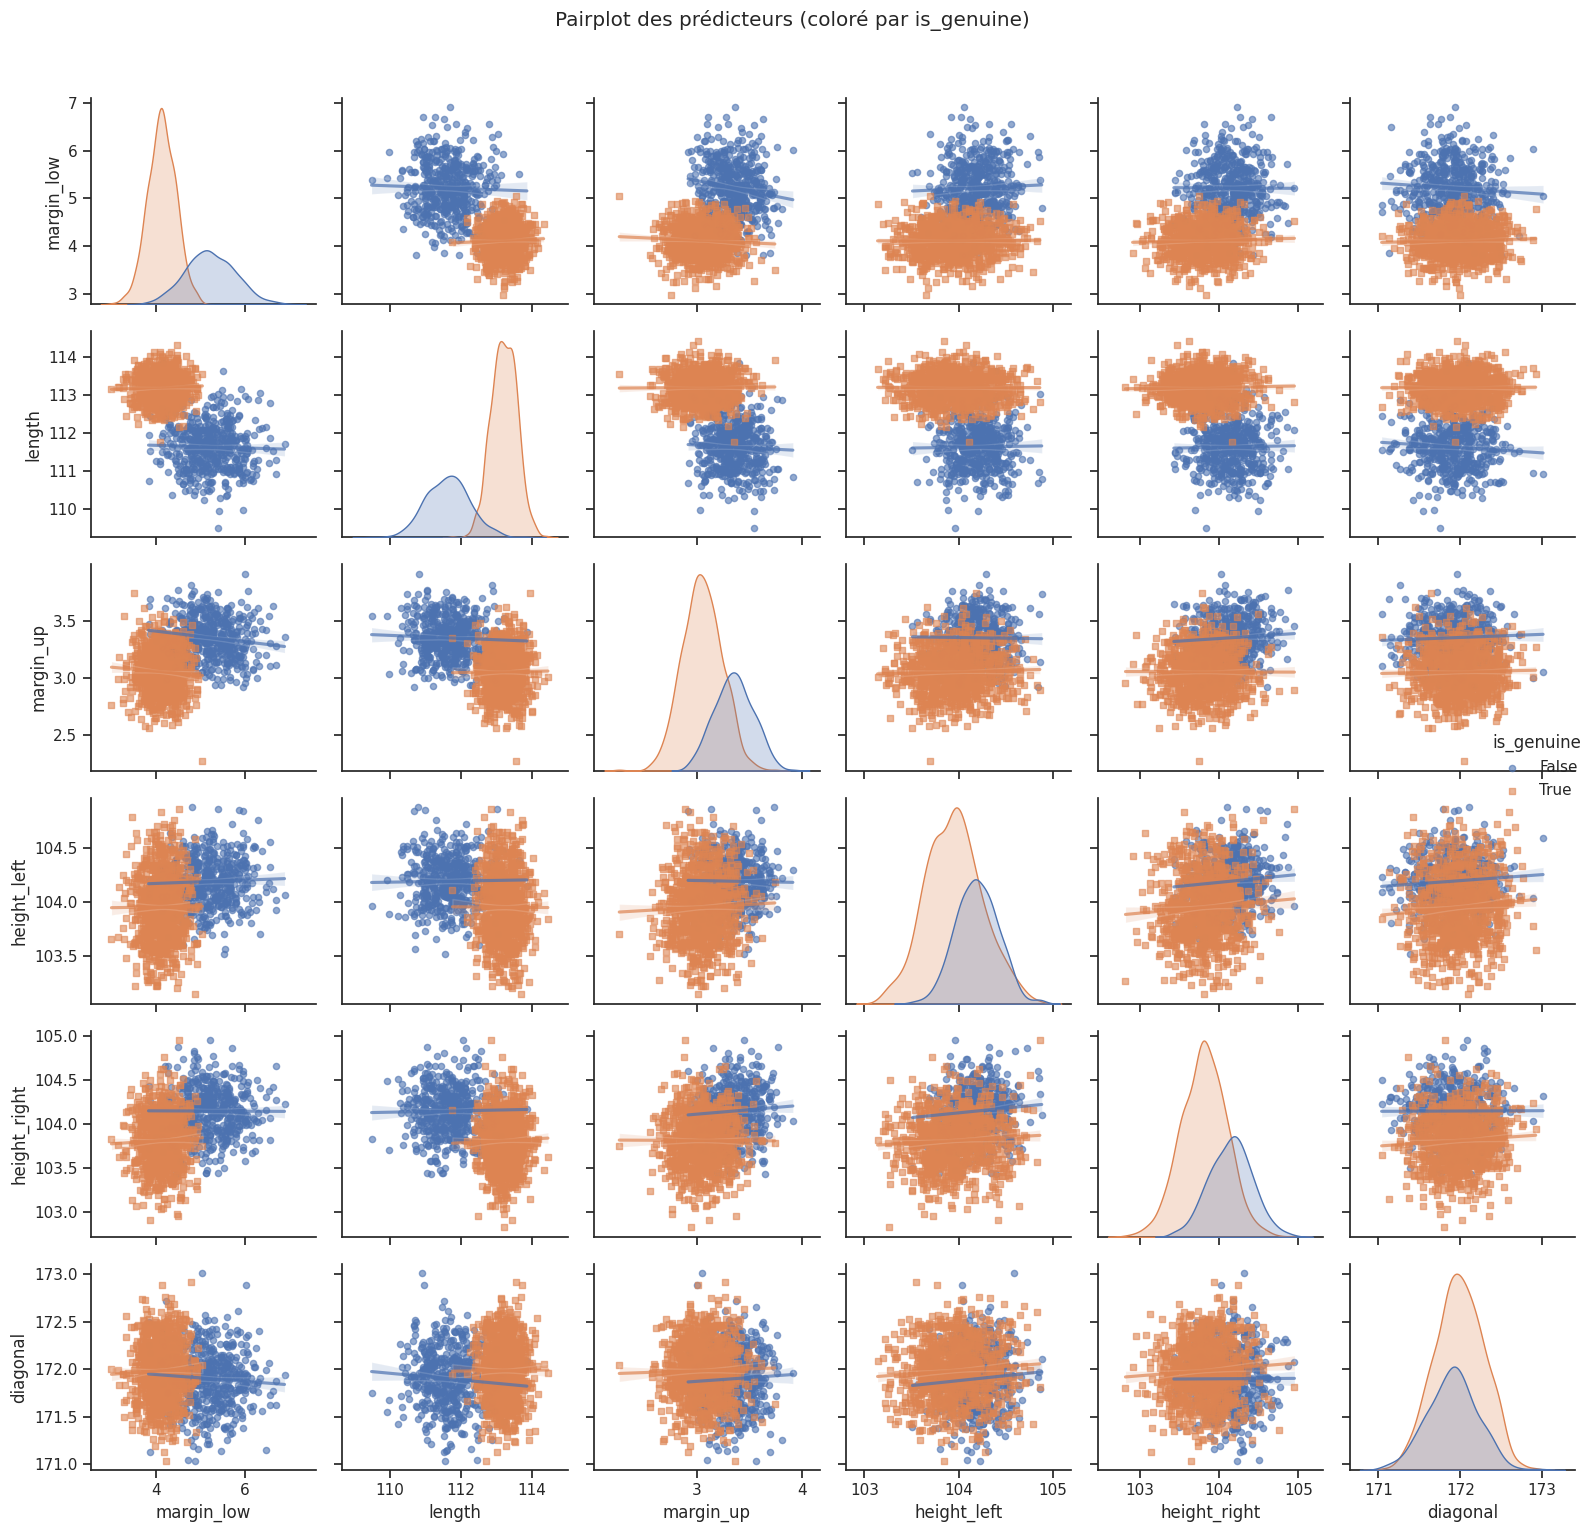

In [ ]:
# Pairplot des prédicteurs

# préparer DataFrame (ajouter la colonne is_genuine pour le hue)
df_plot = df[cols + ['is_genuine']].copy()

# s'assurer que is_genuine est catégorielle (utile pour hue)
df_plot['is_genuine'] = df_plot['is_genuine'].astype('category')

# échantillonner si gros dataset
df_sample = df_plot.sample(n=2000, random_state=0) if len(df_plot) > 2000 else df_plot

# pairplot : colorer par is_genuine, afficher régression sur les scatter plots
sns.set(style="ticks")
g = sns.pairplot(
    df_sample,
    vars=cols,
    hue='is_genuine',
    diag_kind='kde',
    kind='reg',                     # scatter + régression linéaire sur les off-diagonales
    plot_kws={'scatter_kws': {'s': 20, 'alpha': 0.6}, 'line_kws': {'alpha':0.7}},
    palette={False: "C0", True: "C1"},
    markers=['o', 's']
)

plt.suptitle("Pairplot des prédicteurs (coloré par is_genuine)", y=1.02)
plt.tight_layout()
plt.show()


# Préparer jeux et indicateurs d'imputation

In [ ]:
target = 'margin_low'
predictors = ['diagonal','height_left','height_right','margin_up','length']

# Indicateur d'imputation initialisé à False
df[f'{target}_imputed'] = False

# indices d'entraînement (target connu et prédicteurs connus)
train_mask = df[target].notna() & df[predictors].notna().all(axis=1)
X_train = df.loc[train_mask, predictors]
y_train = df.loc[train_mask, target]

# indices à imputer
imputable_mask = df[target].isna() & df[predictors].notna().all(axis=1)
imputable_idx = df.index[imputable_mask]


# REGRESSION LINEAIRE





### Pipelline + cross_validate (une seule passe CV)

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=RND))
])

cv = KFold(n_splits=5, shuffle=True, random_state=RND)
scoring = ['r2', 'neg_mean_squared_error']

cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
r2_mean = cv_res['test_r2'].mean()
rmse_mean = np.sqrt(-cv_res['test_neg_mean_squared_error']).mean()

print("CV R2:", r2_mean, "CV RMSE:", rmse_mean)
# entraînement final sur tout l'ensemble d'entraînement
pipe.fit(X_train, y_train)


CV R2: 0.47189569671692794 CV RMSE: 0.4808365080656641


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', Ridge(random_state=42))])

### Imputation et marquage

In [ ]:
if len(imputable_idx) > 0:
    X_imp = df.loc[imputable_idx, predictors]
    preds = pipe.predict(X_imp)
    df.loc[imputable_idx, target] = preds
    df.loc[imputable_idx, f'{target}_imputed'] = True


### Diagnostic post-imputation

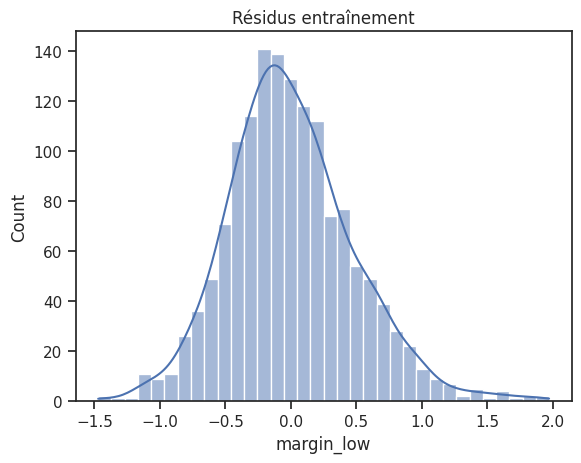

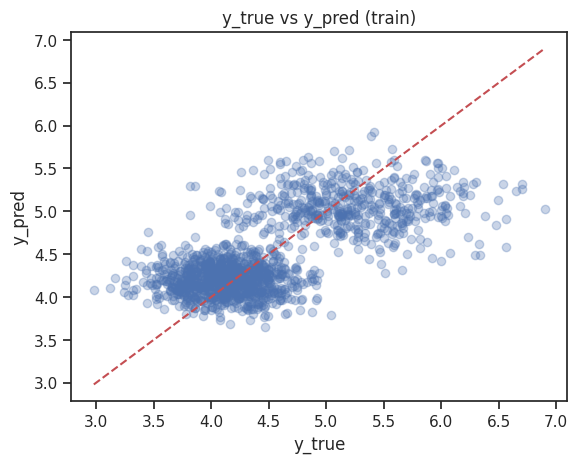

In [ ]:
# résidus sur l'ensemble d'entraînement (diagnostic)
y_pred_train = pipe.predict(X_train)
resid = y_train - y_pred_train
sns.histplot(resid, kde=True); plt.title('Résidus entraînement')
plt.show()

# scatter préd vs réel
plt.scatter(y_train, y_pred_train, alpha=0.3)
plt.xlabel('y_true'); plt.ylabel('y_pred'); plt.title('y_true vs y_pred (train)')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.show()


# Interprétation
Ce que confirment les graphiques :

- Histogramme =>
distribution centrée, densité proche d’une normale mais avec une queue droite plus marquée (quelques prédictions fortement sous‑estimées).

- Scatter y_true vs y_pred => points majoritairement proches de la diagonale (bon ajustement moyen) mais dispersion visible autour de la diagonale ; aucun biais systématique évident, mais des prédictions individuelles peuvent s’écarter sensiblement. Si la dispersion augmente avec y_pred, cela indiquerait de l’hétéroscédasticité.

In [ ]:
resid.describe()

,margin_low
count,1.463000e+03
mean,-5.828102e-17
std,4.799064e-01
min,-1.471828e+00
25%,-3.171133e-01
50%,-4.152680e-02
75%,2.736258e-01
max,1.970673e+00


# Conclusion

Le modèle n’a pas de biais moyen et peut être utilisé pour imputer margin_low, mais la variabilité des prédictions (σ≈0.48) et la présence de quelques erreurs extrêmes imposent prudence : pour des usages exigeant une forte précision, amélioration du modèle ou méthode d’imputation plus robuste est recommandée.

## Cet output n'a plus de valeurs manquantes.

De ce fait, il sera utiliser pour entraîner et tester les modèles algorithmiques retenus.

In [ ]:
joblib.dump(pipe, 'ridge_margin_low_pipeline.joblib')
df.to_csv('/content/drive/MyDrive/data_P12/billets_imputed.csv', index=False)


# REGRESSION LOGISTIQUE

In [ ]:
# CHARGER LES DONNEES
# chemin vers le CSV
CSV_PATH = "/content/drive/MyDrive/data_P12/billets_imputed.csv"

df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df.columns)


(1500, 8)
Index(['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length', 'margin_low_imputed'],
      dtype='object')


In [ ]:
df[df['margin_low_imputed']]

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length,margin_low_imputed
72,True,171.94,103.89,103.45,4.318552,3.25,112.79,True
99,True,171.93,104.07,104.18,4.393843,3.14,113.08,True
151,True,172.07,103.80,104.38,4.410511,3.02,112.93,True
197,True,171.45,103.66,103.80,4.319416,3.62,113.27,True
241,True,171.83,104.14,104.06,4.650462,3.02,112.36,True
251,True,171.80,103.26,102.82,3.803226,2.95,113.22,True
284,True,171.92,103.83,103.76,4.179966,3.23,113.29,True
334,True,171.85,103.70,103.96,4.127595,3.00,113.36,True
410,True,172.56,103.72,103.51,4.135042,3.12,112.95,True
413,True,172.30,103.66,103.50,4.160561,3.16,112.95,True


In [ ]:
TARGET = 'margin_low_imputed'   # adapter si nécessaire

# Vérifier la cible
print(df[TARGET].value_counts(dropna=False))

# Sélectionner prédicteurs (exemple : toutes les colonnes numériques sauf la target)
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Garder uniquement colonnes numériques ou encoder les catégorielles
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()
print("Numériques:", num_cols)
print("Catégorielles:", cat_cols)


margin_low_imputed
False    1463
True       37
Name: count, dtype: int64
Numériques: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Catégorielles: ['is_genuine']


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import sklearn

print("scikit-learn version:", sklearn.__version__)

# Compatibilité OneHotEncoder pour anciennes et nouvelles versions
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    # fallback pour versions plus anciennes
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)



scikit-learn version: 1.6.1


Train rows: 1500 To impute: 0
Validation RMSE: 0.4768, R2: 0.4837


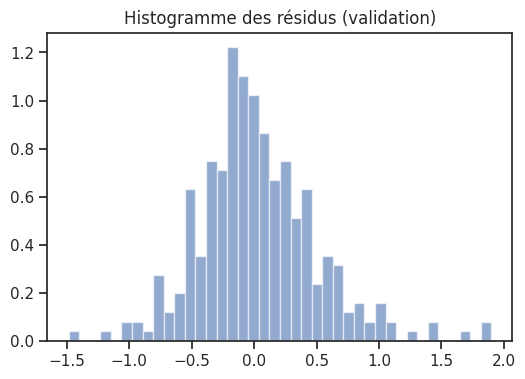

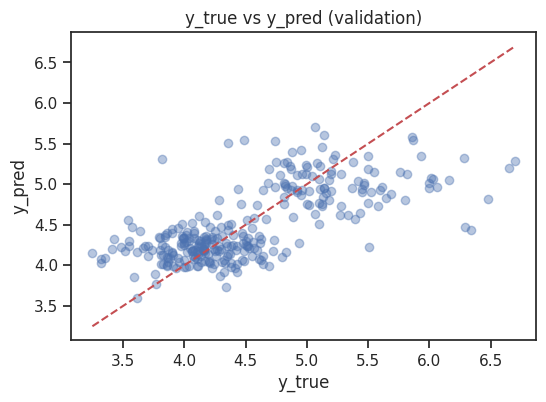

Train RMSE: 0.4737885605595353
Train R2: 0.48375010994715484


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib


# 1) Définir target et prédicteurs (exclure is_genuine)
TARGET = 'margin_low'
drop_cols = ['is_genuine']  # colonnes à exclure des prédicteurs
predictors = ['diagonal','height_left','height_right','margin_up','length']  # ajuster si besoin

# 2) Indices pour entraînement (target connu) et pour imputer (target manquant mais prédicteurs connus)
train_mask = df[TARGET].notna() & df[predictors].notna().all(axis=1)
imputable_mask = df[TARGET].isna() & df[predictors].notna().all(axis=1)

X_train = df.loc[train_mask, predictors].copy()
y_train = df.loc[train_mask, TARGET].copy()
X_impute = df.loc[imputable_mask, predictors].copy()
imputable_idx = df.index[imputable_mask]

print("Train rows:", X_train.shape[0], "To impute:", X_impute.shape[0])

# 3) Pipeline simple (imputer pour prédicteurs si nécessaire + scaler + modèle)
#    On n'impute pas la cible ici : on entraîne uniquement sur y connus.
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # si jamais un prédicteur a des NaN
    ('scaler', StandardScaler()),
    # utiliser RidgeCV pour régulariser automatiquement (évite overfit)
    ('reg', RidgeCV(alphas=[0.1, 1.0, 10.0], scoring='neg_mean_squared_error', cv=5))
])

# 4) Split interne pour diagnostics (optionnel)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

pipeline.fit(X_tr, y_tr)

# 5) Diagnostics sur validation
y_val_pred = pipeline.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)
print(f"Validation RMSE: {rmse_val:.4f}, R2: {r2_val:.4f}")

# Résidus et graphiques
resid = y_val - y_val_pred
plt.figure(figsize=(6,4))
plt.hist(resid, bins=40, density=True, alpha=0.6)
plt.title("Histogramme des résidus (validation)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('y_true'); plt.ylabel('y_pred'); plt.title('y_true vs y_pred (validation)')
plt.show()

# 6) Entraîner sur tout l'ensemble d'entraînement disponible
pipeline.fit(X_train, y_train)

# 7) Évaluer sur l'ensemble d'entraînement complet (diagnostic)
y_train_pred = pipeline.predict(X_train)
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train R2:", r2_score(y_train, y_train_pred))

# 8) Imputer les valeurs manquantes (prédire puis remplir)
if X_impute.shape[0] > 0:
    preds = pipeline.predict(X_impute)
    df.loc[imputable_idx, TARGET] = preds
    # marquer l'indicateur d'imputation
    df.loc[imputable_idx, 'margin_low_imputed'] = True
    print(f"Imputées {len(preds)} valeurs de {TARGET}.")

# 9) Sauvegarder DataFrame et modèle
#df.to_csv('/content/drive/MyDrive/data_P12/billets_imputed_final.csv', index=False)
#joblib.dump(pipeline, '/content/drive/MyDrive/data_P12/regression_margin_low_model.joblib')
#print("DataFrame et modèle sauvegardés.")


# Interprétation des métriques

R² = 0.48 : le modèle capte une part substantielle mais loin d’être majoritaire de la variabilité. Il reste ~52 % de variance non expliquée (bruit, variables manquantes, non‑linéarités).

RMSE = 0.47 : interpréter par rapport à l’échelle de margin_low (min/max observés). Si la cible varie typiquement sur un intervalle de ~[−1.5, 2.0], une erreur moyenne de 0.47 est modérée.

Risque d’overfit/underfit : ces valeurs seules ne disent pas si le modèle sur‑apprend. Comparez RMSE/R² entraînement vs validation/CV pour détecter sur‑apprentissage.
Calculer CV RMSE pour robustesse.

# REGRESSION LOGISTIQUE

Colonnes numériques utilisées: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Colonnes catégorielles utilisées: []


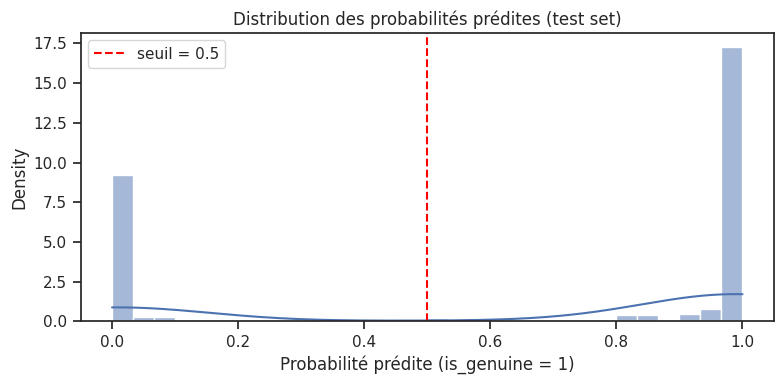

=== Métriques (seuil = 0.50) ===
Accuracy :  0.9900
Precision:  0.9950
Recall   :  0.9900
F1-score :  0.9925
ROC AUC  :  0.9995

Classification report :

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       100
           1       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



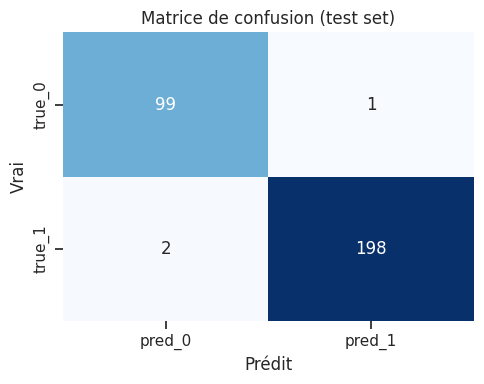

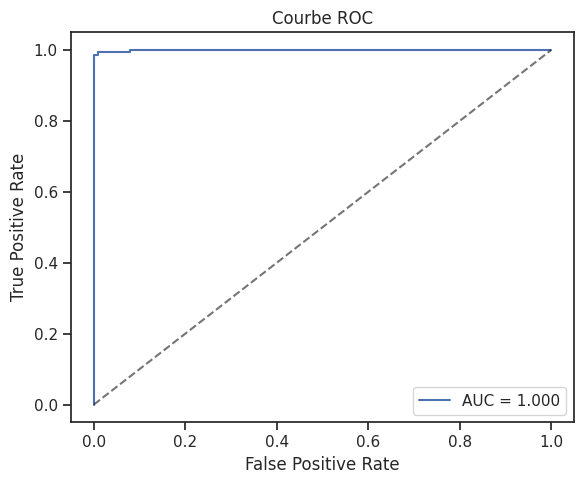

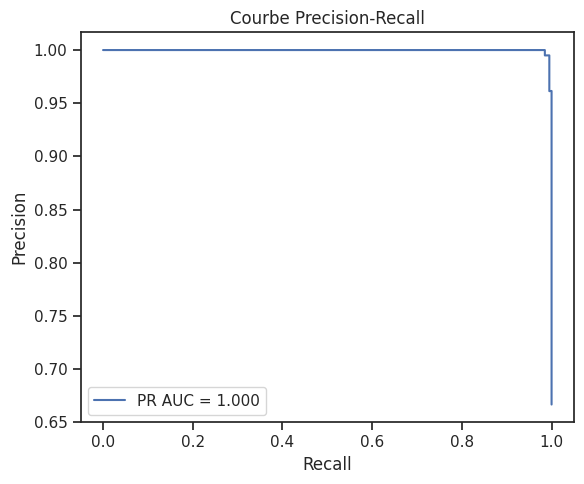

,threshold,precision,recall,f1,accuracy
44,0.44,0.99500,0.995,0.995000,0.993333
41,0.41,0.99500,0.995,0.995000,0.993333
42,0.42,0.99500,0.995,0.995000,0.993333
43,0.43,0.99500,0.995,0.995000,0.993333
40,0.40,0.99500,0.995,0.995000,0.993333
45,0.45,0.99500,0.995,0.995000,0.993333
46,0.46,0.99500,0.995,0.995000,0.993333
29,0.29,0.99005,0.995,0.992519,0.990000
32,0.32,0.99005,0.995,0.992519,0.990000
33,0.33,0.99005,0.995,0.992519,0.990000


Coefficients du modèle (ordre décroissant d'importance absolue) :


,feature,coef
5,num__length,3.712133
3,num__margin_low,-2.590132
4,num__margin_up,-1.669852
2,num__height_right,-0.704223
1,num__height_left,-0.308307
0,num__diagonal,0.163572


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)

# --- paramètres ---
DF = df.copy()
TARGET = 'is_genuine'
TEST_SIZE = 0.2
RANDOM_STATE = 42
PROBA_THRESHOLD = 0.5
MODEL_PATH = '/content/drive/MyDrive/data_P12/billets_imputed.csv'  # adapter si besoin

# --- vérifier la cible ---
if TARGET not in DF.columns:
    raise ValueError(f"Colonne cible {TARGET} introuvable dans le DataFrame")

# --- définir X et y ---
# X = toutes les colonnes sauf la cible
X = DF.drop(columns=[TARGET, 'margin_low_imputed']).copy()
y = DF[TARGET].astype(int).copy()

# --- séparer colonnes numériques et catégorielles ---
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Colonnes numériques utilisées:", num_cols)
print("Colonnes catégorielles utilisées:", cat_cols)

# --- filtrer lignes valides (on laisse l'imputation aux transformers) ---
mask = X.notna().all(axis=1) | True  # on laisse pipeline imputer; on retire seulement si y manquant
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

# --- split stratifié ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# --- OneHotEncoder compatible (gestion versions sklearn) ---
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

# --- préprocesseurs ---
num_transformer = Pipeline([
    ('scaler', StandardScaler())
])


preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols)], remainder='drop')

# --- pipeline complet ---
pipeline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE))
])

# --- entraînement ---
pipeline.fit(X_train, y_train)

# --- probabilités et prédictions ---
proba_pos = pipeline.predict_proba(X_test)[:, 1]
y_pred = (proba_pos >= PROBA_THRESHOLD).astype(int)

# --- histogramme des probabilités ---
plt.figure(figsize=(8,4))
sns.histplot(proba_pos, bins=30, kde=True, stat='density', color='C0')
plt.axvline(PROBA_THRESHOLD, color='red', linestyle='--', label=f"seuil = {PROBA_THRESHOLD}")
plt.xlabel("Probabilité prédite (is_genuine = 1)")
plt.title("Distribution des probabilités prédites (test set)")
plt.legend()
plt.tight_layout()
plt.show()

# --- métriques ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, proba_pos) if len(np.unique(y_test)) > 1 else np.nan

print("=== Métriques (seuil = {:.2f}) ===".format(PROBA_THRESHOLD))
print(f"Accuracy :  {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall   :  {rec:.4f}")
print(f"F1-score :  {f1:.4f}")
print(f"ROC AUC  :  {roc_auc:.4f}")
print("\nClassification report :\n")
print(classification_report(y_test, y_pred, zero_division=0))

# --- matrice de confusion annotée ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred_0','pred_1'], yticklabels=['true_0','true_1'])
plt.ylabel("Vrai")
plt.xlabel("Prédit")
plt.title("Matrice de confusion (test set)")
plt.tight_layout()
plt.show()

# --- courbe ROC ---
if not np.isnan(roc_auc):
    fpr, tpr, _ = roc_curve(y_test, proba_pos)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Courbe ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- courbe Precision-Recall ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba_pos)
pr_auc = auc(recall_vals, precision_vals)
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.legend()
plt.tight_layout()
plt.show()

# --- grille de seuils pour choisir seuil métier ---
thresholds = np.linspace(0,1,101)
rows = []
for t in thresholds:
    y_t = (proba_pos >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, y_t, zero_division=0),
        'recall': recall_score(y_test, y_t, zero_division=0),
        'f1': f1_score(y_test, y_t, zero_division=0),
        'accuracy': accuracy_score(y_test, y_t)
    })
th_df = pd.DataFrame(rows)
display(th_df.sort_values('f1', ascending=False).head(10))

# --- coefficients pour interprétation (si modèle linéaire) ---
# récupérer noms de features après transformation
feat_names = pipeline.named_steps['preproc'].get_feature_names_out()
coef = pipeline.named_steps['clf'].coef_.ravel()
coef_df = pd.DataFrame({'feature': feat_names, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).drop(columns='abs_coef')
print("Coefficients du modèle (ordre décroissant d'importance absolue) :")
display(coef_df)

# --- sauvegarde du pipeline et des probabilités dans df ---
#joblib.dump(pipeline, MODEL_PATH)
#print("Pipeline sauvegardé dans", MODEL_PATH)

# ajouter probabilités au DataFrame original (alignement par index)
#probas_all = pipeline.predict_proba(X.fillna(X.mean()))[:,1]
#DF.loc[X.index, 'is_genuine_proba'] = probas_all


# K- NEAREST NEIGHBORS (KNN)

Colonnes numériques utilisées: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Colonnes catégorielles utilisées: []
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Meilleur paramètre: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}


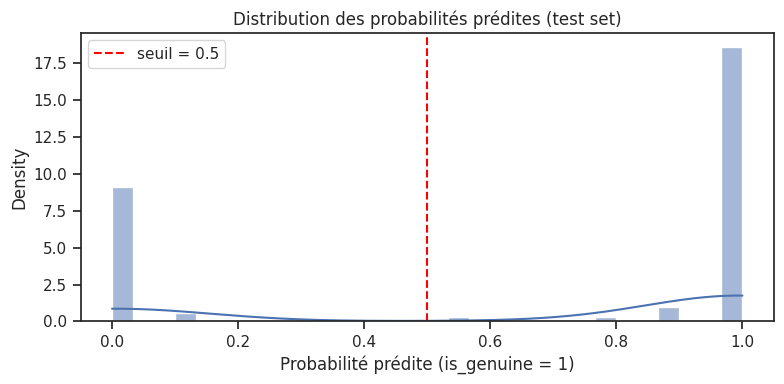

=== Métriques (seuil = 0.50) ===
Accuracy :  0.9867
Precision:  0.9851
Recall   :  0.9950
F1-score :  0.9900
ROC AUC  :  0.9971

Classification report :

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       100
           1       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



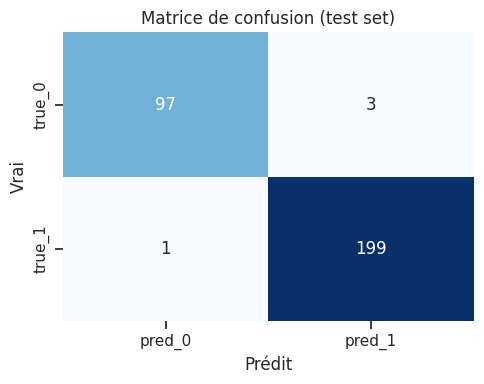

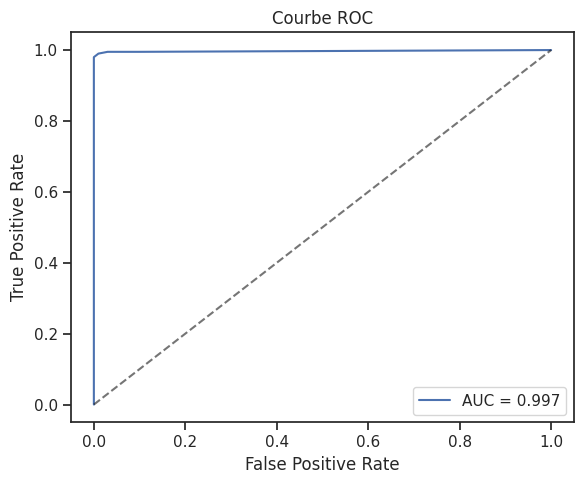

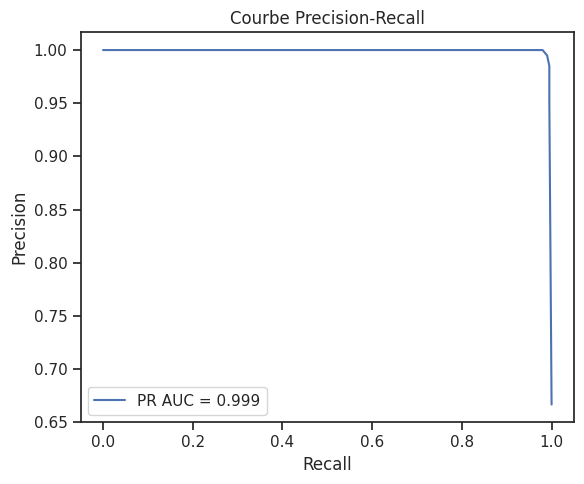

,threshold,precision,recall,f1,accuracy
64,0.64,0.994975,0.99,0.992481,0.99
68,0.68,0.994975,0.99,0.992481,0.99
63,0.63,0.994975,0.99,0.992481,0.99
62,0.62,0.994975,0.99,0.992481,0.99
61,0.61,0.994975,0.99,0.992481,0.99
69,0.69,0.994975,0.99,0.992481,0.99
70,0.70,0.994975,0.99,0.992481,0.99
71,0.71,0.994975,0.99,0.992481,0.99
56,0.56,0.994975,0.99,0.992481,0.99
60,0.60,0.994975,0.99,0.992481,0.99


CV ROC AUC mean ± std: 0.99243 0.0032011482314944152
Pipeline sauvegardé dans /content/drive/MyDrive/data_P12/billets_imputed.csv


In [ ]:
# KNN

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)

# --- paramètres ---
DF = df.copy()
TARGET = 'is_genuine'
TEST_SIZE = 0.2
RANDOM_STATE = 42
PROBA_THRESHOLD = 0.5
MODEL_PATH = '/content/drive/MyDrive/data_P12/billets_imputed.csv'
N_NEIGHBORS_GRID = [3,5,7,9]   # grille simple pour GridSearchCV
CV_FOLDS = 5

# --- vérifier la cible ---
if TARGET not in DF.columns:
    raise ValueError(f"Colonne cible {TARGET} introuvable dans le DataFrame")

# --- définir X et y (exclure explicitement margin_low_imputed si présent) ---
drop_cols = [TARGET]
if 'margin_low_imputed' in DF.columns:
    drop_cols.append('margin_low_imputed')
X = DF.drop(columns=drop_cols).copy()
y = DF[TARGET].astype(int).copy()

# --- séparer colonnes numériques et catégorielles ---
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Colonnes numériques utilisées:", num_cols)
print("Colonnes catégorielles utilisées:", cat_cols)

# --- split stratifié (on conserve indices pour réinjection des proba) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# --- transformers ---
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

# --- pipeline KNN (sans hyperparam tuning) ---
knn = KNeighborsClassifier()
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', knn)
])

# --- GridSearchCV pour choisir n_neighbors via CV sur l'ensemble d'entraînement ---
param_grid = {'clf__n_neighbors': N_NEIGHBORS_GRID, 'clf__weights': ['uniform','distance']}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)

print("Meilleur paramètre:", gs.best_params_)
best_model = gs.best_estimator_

# --- probabilités et prédictions sur test set ---
proba_pos = best_model.predict_proba(X_test)[:,1]
y_pred = (proba_pos >= PROBA_THRESHOLD).astype(int)

# --- histogramme des probabilités ---
plt.figure(figsize=(8,4))
sns.histplot(proba_pos, bins=30, kde=True, stat='density', color='C0')
plt.axvline(PROBA_THRESHOLD, color='red', linestyle='--', label=f"seuil = {PROBA_THRESHOLD}")
plt.xlabel("Probabilité prédite (is_genuine = 1)")
plt.title("Distribution des probabilités prédites (test set)")
plt.legend()
plt.tight_layout()
plt.show()

# --- métriques ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, proba_pos) if len(np.unique(y_test)) > 1 else np.nan

print("=== Métriques (seuil = {:.2f}) ===".format(PROBA_THRESHOLD))
print(f"Accuracy :  {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall   :  {rec:.4f}")
print(f"F1-score :  {f1:.4f}")
print(f"ROC AUC  :  {roc_auc:.4f}")
print("\nClassification report :\n")
print(classification_report(y_test, y_pred, zero_division=0))

# --- matrice de confusion annotée ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred_0','pred_1'], yticklabels=['true_0','true_1'])
plt.ylabel("Vrai")
plt.xlabel("Prédit")
plt.title("Matrice de confusion (test set)")
plt.tight_layout()
plt.show()

# --- courbe ROC ---
if not np.isnan(roc_auc):
    fpr, tpr, _ = roc_curve(y_test, proba_pos)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Courbe ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- courbe Precision-Recall ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba_pos)
pr_auc = auc(recall_vals, precision_vals)
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.legend()
plt.tight_layout()
plt.show()

# --- grille de seuils pour choisir seuil métier ---
thresholds = np.linspace(0,1,101)
rows = []
for t in thresholds:
    y_t = (proba_pos >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, y_t, zero_division=0),
        'recall': recall_score(y_test, y_t, zero_division=0),
        'f1': f1_score(y_test, y_t, zero_division=0),
        'accuracy': accuracy_score(y_test, y_t)
    })
th_df = pd.DataFrame(rows)
display(th_df.sort_values('f1', ascending=False).head(10))

# --- cross validation AUC sur tout X pour robustesse ---
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print("CV ROC AUC mean ± std:", cv_scores.mean(), cv_scores.std())

# --- sauvegarde du pipeline et ajout des probabilités au DataFrame original ---
joblib.dump(best_model, MODEL_PATH)
print("Pipeline sauvegardé dans", MODEL_PATH)

# calculer probabilités pour toutes les lignes (imputer manuellement les NaN si nécessaire)
X_all = X.copy()
# appliquer imputation simple pour obtenir proba sur tout df
X_all_filled = X_all.fillna(X_all.mean())
probas_all = best_model.predict_proba(X_all_filled)[:,1]
DF.loc[X_all.index, 'is_genuine_proba_knn'] = probas_all


# RANDOM FOREST

Colonnes numériques utilisées: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Colonnes catégorielles utilisées: []
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Meilleurs paramètres: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}


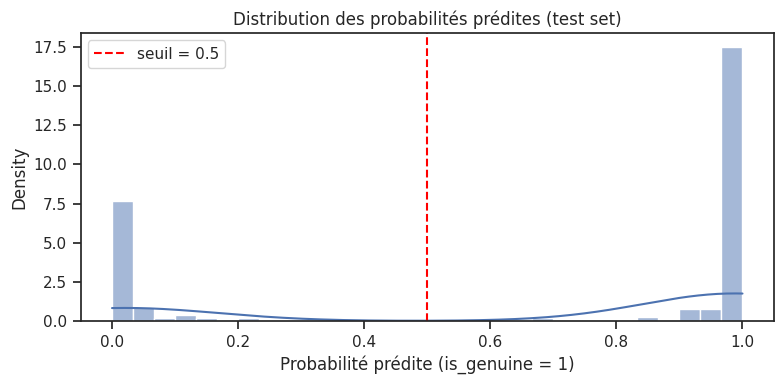

=== Métriques (seuil = 0.50) ===
Accuracy :  0.9900
Precision:  0.9900
Recall   :  0.9950
F1-score :  0.9925
ROC AUC  :  0.9992

Classification report :

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



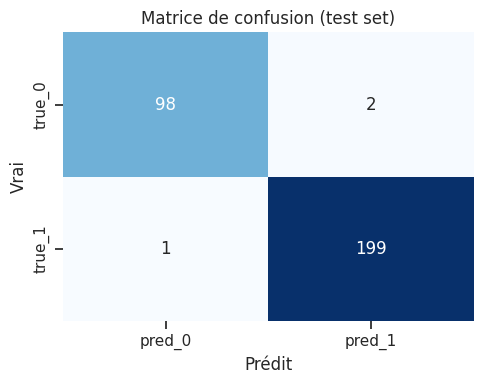

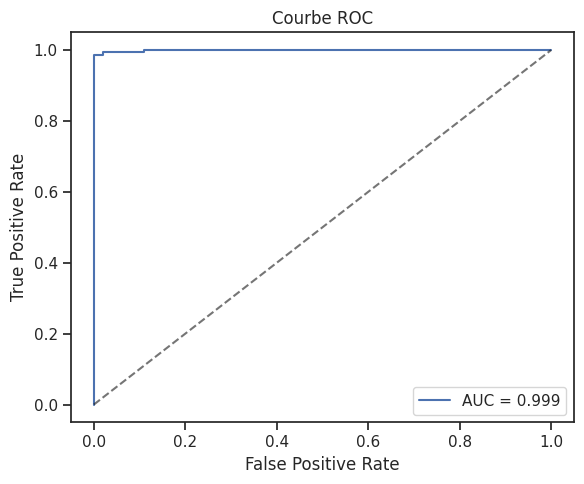

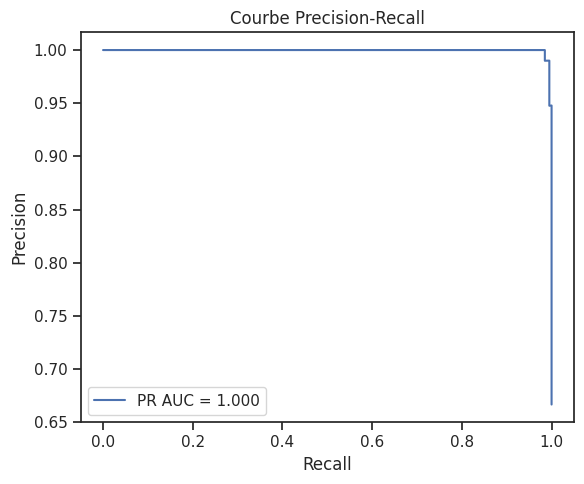

,threshold,precision,recall,f1,accuracy
44,0.44,0.99005,0.995,0.992519,0.99
41,0.41,0.99005,0.995,0.992519,0.99
42,0.42,0.99005,0.995,0.992519,0.99
43,0.43,0.99005,0.995,0.992519,0.99
40,0.40,0.99005,0.995,0.992519,0.99
53,0.53,0.99005,0.995,0.992519,0.99
54,0.54,0.99005,0.995,0.992519,0.99
55,0.55,0.99005,0.995,0.992519,0.99
52,0.52,0.99005,0.995,0.992519,0.99
48,0.48,0.99005,0.995,0.992519,0.99


CV ROC AUC mean ± std: 0.999385 0.00040638651552429145
Permutation importances (moyenne):
 length          0.261778
margin_low      0.151333
margin_up       0.008556
height_right    0.003222
height_left     0.002444
diagonal        0.000000
dtype: float64
Pipeline sauvegardé dans /content/drive/MyDrive/data_P12/billets_imputed.csv


In [ ]:
# RandomForest_is_genuine.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc
)
from sklearn.inspection import permutation_importance

# --- paramètres ---
DF = df.copy()                                # df doit être en mémoire
TARGET = 'is_genuine'
DROP_IF_PRESENT = ['margin_low_imputed']      # colonnes à exclure explicitement
TEST_SIZE = 0.2
RANDOM_STATE = 42
PROBA_THRESHOLD = 0.5
MODEL_PATH = '/content/drive/MyDrive/data_P12/billets_imputed.csv'  # adapter si besoin
N_JOBS = -1

# --- vérifier la cible ---
if TARGET not in DF.columns:
    raise ValueError(f"Colonne cible {TARGET} introuvable dans le DataFrame")

# --- définir X et y (exclure la cible et colonnes listées) ---
drop_cols = [TARGET] + [c for c in DROP_IF_PRESENT if c in DF.columns]
X = DF.drop(columns=drop_cols).copy()
y = DF[TARGET].astype(int).copy()

# --- séparer colonnes numériques et catégorielles ---
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Colonnes numériques utilisées:", num_cols)
print("Colonnes catégorielles utilisées:", cat_cols)

# --- split stratifié ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# --- OneHotEncoder compatibilité ---
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

# --- préprocesseurs ---
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

# --- pipeline complet avec RandomForest ---
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)  # n_jobs géré par GridSearchCV
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', rf)
])

# --- grille d'hyperparamètres (ajuster si besoin) ---
param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_leaf': [1, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe, param_grid, scoring='roc_auc', cv=cv, n_jobs=N_JOBS, verbose=1)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
print("Meilleurs paramètres:", gs.best_params_)

# --- probabilités et prédictions sur test set ---
proba_pos = best_model.predict_proba(X_test)[:, 1]
y_pred = (proba_pos >= PROBA_THRESHOLD).astype(int)

# --- histogramme des probabilités ---
plt.figure(figsize=(8,4))
sns.histplot(proba_pos, bins=30, kde=True, stat='density', color='C0')
plt.axvline(PROBA_THRESHOLD, color='red', linestyle='--', label=f"seuil = {PROBA_THRESHOLD}")
plt.xlabel("Probabilité prédite (is_genuine = 1)")
plt.title("Distribution des probabilités prédites (test set)")
plt.legend()
plt.tight_layout()
plt.show()

# --- métriques ---
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, proba_pos) if len(np.unique(y_test)) > 1 else np.nan

print("=== Métriques (seuil = {:.2f}) ===".format(PROBA_THRESHOLD))
print(f"Accuracy :  {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall   :  {rec:.4f}")
print(f"F1-score :  {f1:.4f}")
print(f"ROC AUC  :  {roc_auc:.4f}")
print("\nClassification report :\n")
print(classification_report(y_test, y_pred, zero_division=0))

# --- matrice de confusion annotée ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pred_0','pred_1'], yticklabels=['true_0','true_1'])
plt.ylabel("Vrai")
plt.xlabel("Prédit")
plt.title("Matrice de confusion (test set)")
plt.tight_layout()
plt.show()

# --- courbe ROC ---
if not np.isnan(roc_auc):
    fpr, tpr, _ = roc_curve(y_test, proba_pos)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'k--', alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Courbe ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- courbe Precision-Recall ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba_pos)
pr_auc = auc(recall_vals, precision_vals)
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall")
plt.legend()
plt.tight_layout()
plt.show()

# --- grille de seuils pour choisir seuil métier ---
thresholds = np.linspace(0,1,101)
rows = []
for t in thresholds:
    y_t = (proba_pos >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, y_t, zero_division=0),
        'recall': recall_score(y_test, y_t, zero_division=0),
        'f1': f1_score(y_test, y_t, zero_division=0),
        'accuracy': accuracy_score(y_test, y_t)
    })
th_df = pd.DataFrame(rows)
display(th_df.sort_values('f1', ascending=False).head(10))

# --- cross validation AUC sur tout X pour robustesse ---
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc', n_jobs=N_JOBS)
print("CV ROC AUC mean ± std:", cv_scores.mean(), cv_scores.std())

# --- permutation importance sur test set ---
perm = permutation_importance(best_model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, n_jobs=N_JOBS)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Permutation importances (moyenne):\n", imp)

# --- sauvegarde du pipeline et ajout des probabilités au DataFrame original ---
joblib.dump(best_model, MODEL_PATH)
print("Pipeline sauvegardé dans", MODEL_PATH)

# calculer probabilités pour toutes les lignes (imputer manuellement les NaN si nécessaire)
X_all = X.copy()
X_all_filled = X_all.fillna(X_all.mean())
probas_all = best_model.predict_proba(X_all_filled)[:,1]
DF.loc[X_all.index, 'is_genuine_proba_rf'] = probas_all


# K-MEANS

In [ ]:
# Imports et paramètres
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, homogeneity_score,
    completeness_score, confusion_matrix
)

# --- paramètres ---
DF = df.copy()  # votre DataFrame déjà nettoyé et imputé par régression
TARGET = 'is_genuine'
TEST_SIZE = 0.2
RANDOM_STATE = 42
MODEL_PATH = '/content/drive/MyDrive/data_P12/billets_imputed.csv'  # adapter si besoin

# Colonnes à supprimer si présentes
DROP_IF_PRESENT = ['margin_low_imputed']


In [ ]:
# Vérifications de base et définition X, y (en tenant compte de DROP_IF_PRESENT)
if TARGET not in DF.columns:
    raise ValueError(f"Colonne cible {TARGET} introuvable dans le DataFrame")

# Supprimer la/les colonnes optionnelles si présentes
cols_to_drop = [TARGET] + [c for c in DROP_IF_PRESENT if c in DF.columns]
X = DF.drop(columns=cols_to_drop, errors='ignore').copy()
y = DF[TARGET].astype(int).copy()

# Vérifier qu'il n'y a plus de valeurs manquantes
missing_per_col = X.isna().sum()
if missing_per_col.sum() > 0:
    print("Attention : il reste des valeurs manquantes (vérifiez l'imputation).")
    print(missing_per_col[missing_per_col > 0])
else:
    print("Aucune valeur manquante détectée dans X (ok).")

# Vérifier que toutes les colonnes sont numériques
non_num = X.select_dtypes(exclude=['number']).columns.tolist()
if len(non_num) > 0:
    raise ValueError(f"Le jeu contient des colonnes non numériques : {non_num}")

num_cols = X.columns.tolist()
print("Colonnes numériques utilisées:", num_cols)
print("Colonnes supprimées (si présentes):", [c for c in DROP_IF_PRESENT if c not in X.columns])


Aucune valeur manquante détectée dans X (ok).
Colonnes numériques utilisées: ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
Colonnes supprimées (si présentes): ['margin_low_imputed']


In [ ]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

# Préprocesseur : StandardScaler uniquement
num_transformer = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols)
], remainder='drop')

# Pipeline de transformation et application
transformer_pipeline = Pipeline([('preproc', preprocessor)])
X_train_trans = transformer_pipeline.fit_transform(X_train)
X_test_trans = transformer_pipeline.transform(X_test)

print("Shape features transformées (train):", X_train_trans.shape)


Shape features transformées (train): (1200, 6)


Scores de silhouette par k : {1: nan, 2: np.float64(0.34451675767820567), 3: np.float64(0.21055523138375326), 4: np.float64(0.19348653445003308), 5: np.float64(0.15501730027672062), 6: np.float64(0.14800249515260602), 7: np.float64(0.14229040983058944), 8: np.float64(0.1414159746932627), 9: np.float64(0.13985639833647773), 10: np.float64(0.13994066482741965)}
Meilleur k selon silhouette : 2 (silhouette=0.3445)


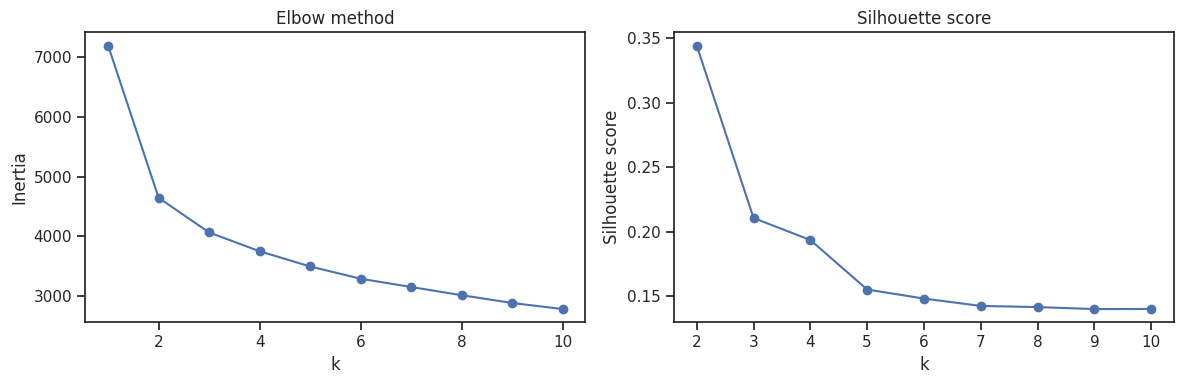

In [ ]:
# Recherche automatique du meilleur k par silhouette
ks = list(range(1, 11))
best_k = None
best_sil = -1
sil_scores = {}

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_trans)
    try:
        sil = silhouette_score(X_train_trans, labels)
    except Exception:
        sil = np.nan
    sil_scores[k] = sil
    if not np.isnan(sil) and sil > best_sil:
        best_sil = sil
        best_k = k

print("Scores de silhouette par k :", sil_scores)
if best_k is None:
    best_k = 3
    print(f"Aucun score silhouette valide ; on prend k={best_k} par défaut.")
else:
    print(f"Meilleur k selon silhouette : {best_k} (silhouette={best_sil:.4f})")

# Visualisation inertie et silhouette pour inspection
inertias = []
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_trans)
    inertias.append(km.inertia_)
    try:
        silhouettes.append(silhouette_score(X_train_trans, labels))
    except Exception:
        silhouettes.append(np.nan)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, '-o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(ks, silhouettes, '-o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette score')
plt.tight_layout()
plt.show()


KMeans k=2  | ARI: 0.9466 | Homogeneity: 0.8900 | Completeness: 0.8900


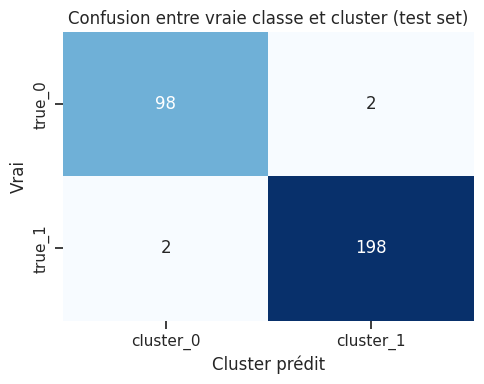

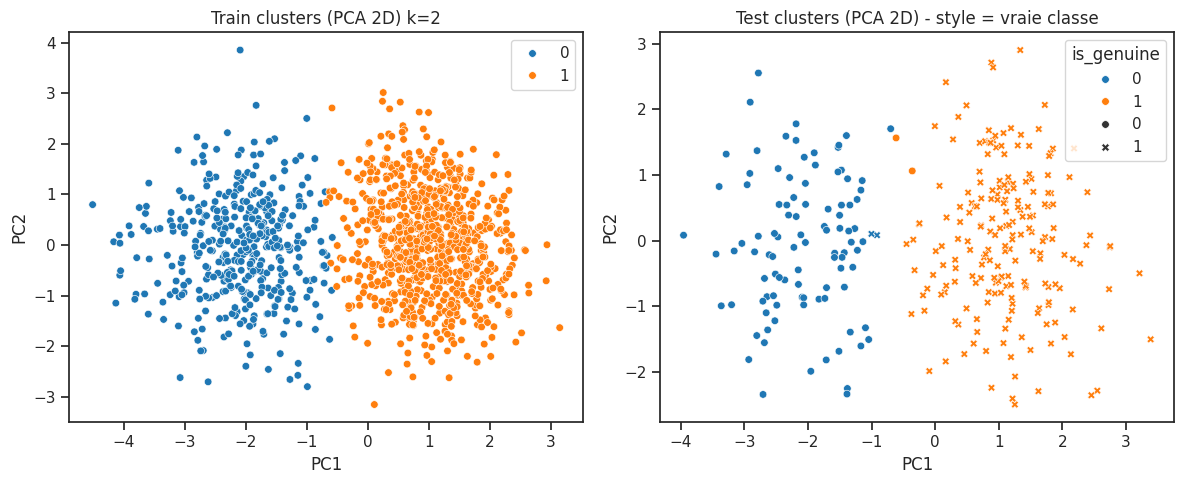

In [ ]:
# Entraînement final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
kmeans.fit(X_train_trans)

# Assignation des clusters
train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test_trans)

# Évaluation par rapport à la vérité
ari = adjusted_rand_score(y_test, test_labels)
homo = homogeneity_score(y_test, test_labels)
compl = completeness_score(y_test, test_labels)
print(f"KMeans k={best_k}  | ARI: {ari:.4f} | Homogeneity: {homo:.4f} | Completeness: {compl:.4f}")

# Matrice de confusion entre vraie classe et cluster
cm = confusion_matrix(y_test, test_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'cluster_{i}' for i in range(best_k)],
            yticklabels=['true_0','true_1'])
plt.ylabel("Vrai"); plt.xlabel("Cluster prédit")
plt.title("Confusion entre vraie classe et cluster (test set)")
plt.tight_layout()
plt.show()

# Visualisation 2D via PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = pca.fit_transform(np.vstack([X_train_trans, X_test_trans]))
n_train = X_train_trans.shape[0]
X_train_vis = X_vis[:n_train]
X_test_vis = X_vis[n_train:]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=X_train_vis[:,0], y=X_train_vis[:,1], hue=train_labels, palette='tab10', s=30, legend='full')
plt.title(f'Train clusters (PCA 2D) k={best_k}'); plt.xlabel('PC1'); plt.ylabel('PC2')

plt.subplot(1,2,2)
sns.scatterplot(x=X_test_vis[:,0], y=X_test_vis[:,1], hue=test_labels, palette='tab10', s=30, legend='full', style=y_test)
plt.title('Test clusters (PCA 2D) - style = vraie classe'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()
